## Adaboost

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df= pd.read_csv('mushrooms.csv')
df.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                8124 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-surface-below-ring  8124 non-null   object
 14  stalk-color-above-ring  

In [5]:
df['class'].value_counts()

class
e    4208
p    3916
Name: count, dtype: int64

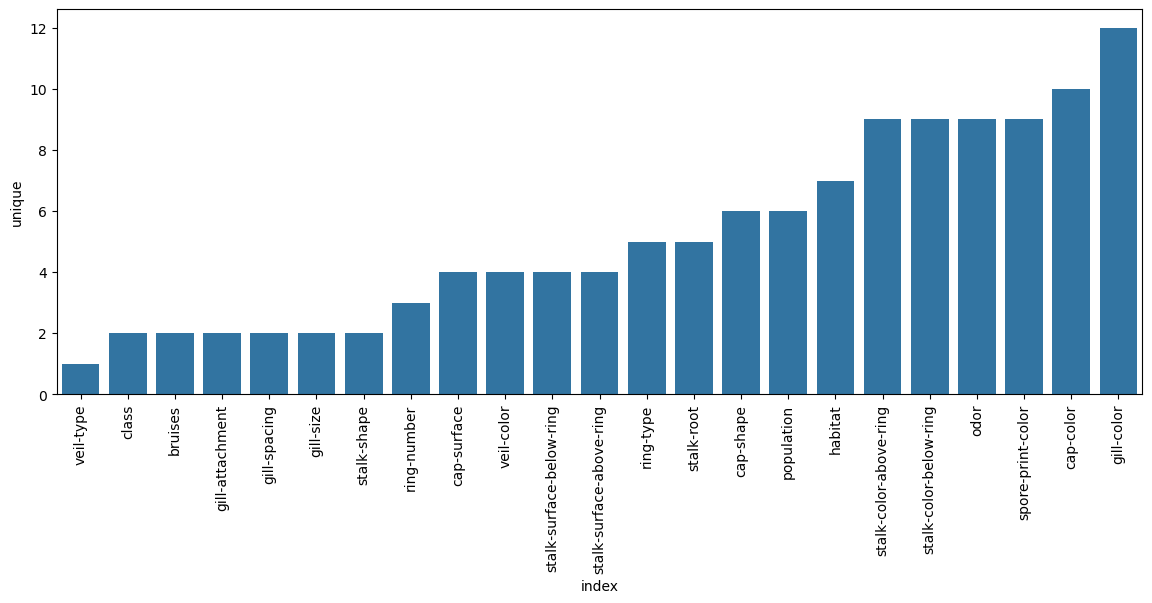

In [12]:
des= df.describe().transpose().reset_index().sort_values('unique')

plt.figure(figsize=[14,5])
sns.barplot(x='index',y='unique',data=des)
plt.xticks(rotation=90)
plt.show()

### Train Test Split

In [13]:
X= df.drop('class',axis=1)
y=df['class']

In [26]:
X=pd.get_dummies(X,drop_first=True)

In [27]:
from sklearn.model_selection import train_test_split

In [28]:
X_train, X_test, y_train, y_test= train_test_split(X,y,test_size=0.15,random_state=101)

### Modelling

In [29]:
from sklearn.ensemble import AdaBoostClassifier

In [44]:
model= AdaBoostClassifier(n_estimators=1)

In [45]:
model.fit(X_train,y_train)

AdaBoostClassifier(n_estimators=1)

In [46]:
from sklearn.metrics import classification_report, accuracy_score

In [47]:
pred= model.predict(X_test)

In [48]:
pred

array(['p', 'e', 'p', ..., 'p', 'p', 'e'], dtype=object)

In [49]:
print(classification_report(y_test,pred))

              precision    recall  f1-score   support

           e       0.96      0.81      0.88       655
           p       0.81      0.96      0.88       564

    accuracy                           0.88      1219
   macro avg       0.88      0.88      0.88      1219
weighted avg       0.89      0.88      0.88      1219



In [50]:
model.feature_importances_

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [51]:
model.feature_importances_.argmax()

np.int64(22)

In [55]:
X.columns[22]

'odor_n'

<Axes: xlabel='odor', ylabel='count'>

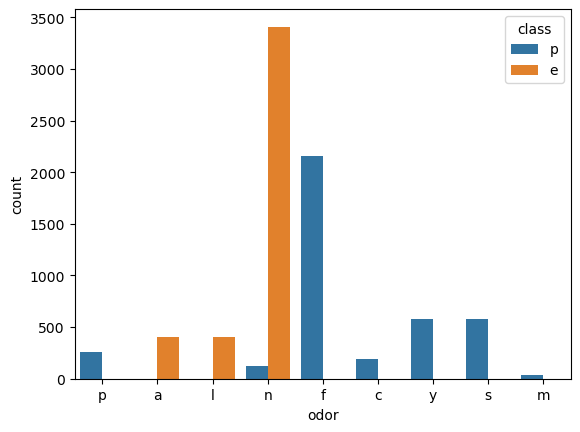

In [56]:
sns.countplot(data=df,x='odor',hue='class')

In [60]:
error_rates=[]
for n in range(1,len(X.columns)+1):
    model=AdaBoostClassifier(n_estimators=n)
    model.fit(X_train, y_train)
    preds=model.predict(X_test)
    error_rates.append((1-accuracy_score(y_test, preds)))

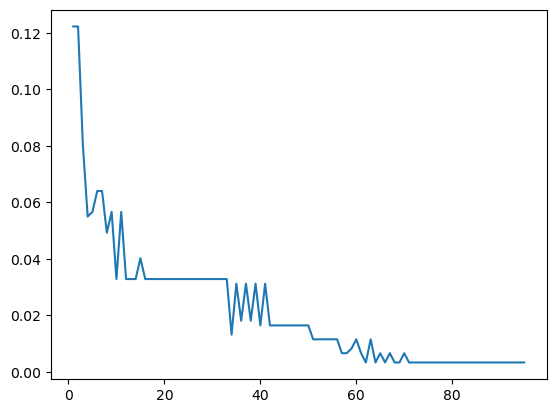

In [61]:
plt.plot(range(1,len(X.columns)+1), error_rates)

In [62]:
model

AdaBoostClassifier(n_estimators=95)

In [63]:
model.feature_importances_

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.08758134, 0.15483051,
       0.03297374, 0.        , 0.07596867, 0.08553577, 0.        ,
       0.        , 0.        , 0.01449336, 0.04761456, 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.02261282, 0.        , 0.01960917, 0.        , 0.        ,
       0.04145947, 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.03716765, 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.02345876, 0.        , 0.     

In [68]:
feats= pd.DataFrame(index= X.columns, data=model.feature_importances_, columns=['Important Features']) #feats= features

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19],
 [Text(0, 0, 'spore-print-color_n'),
  Text(1, 0, 'spore-print-color_u'),
  Text(2, 0, 'gill-spacing_w'),
  Text(3, 0, 'stalk-root_c'),
  Text(4, 0, 'stalk-shape_t'),
  Text(5, 0, 'ring-type_f'),
  Text(6, 0, 'spore-print-color_w'),
  Text(7, 0, 'population_v'),
  Text(8, 0, 'population_c'),
  Text(9, 0, 'odor_l'),
  Text(10, 0, 'ring-type_p'),
  Text(11, 0, 'stalk-color-below-ring_n'),
  Text(12, 0, 'habitat_w'),
  Text(13, 0, 'stalk-surface-above-ring_k'),
  Text(14, 0, 'gill-size_n'),
  Text(15, 0, 'odor_n'),
  Text(16, 0, 'odor_p'),
  Text(17, 0, 'odor_c'),
  Text(18, 0, 'odor_f'),
  Text(19, 0, 'spore-print-color_r')])

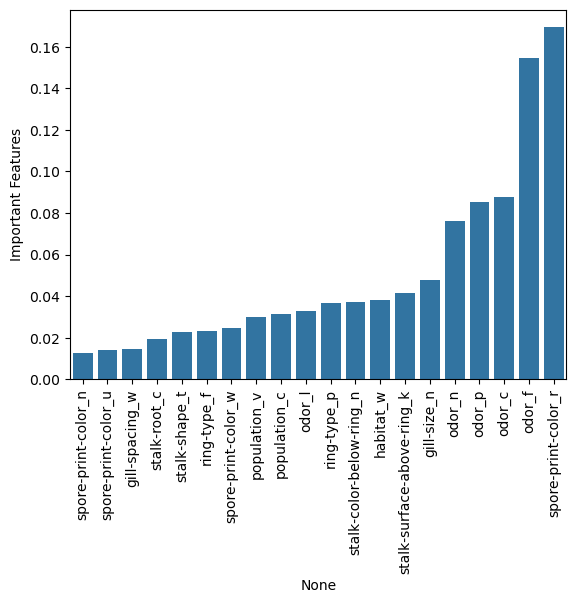

In [71]:
imp_feats= feats[feats['Important Features']>0] # important features

imp_feats= imp_feats.sort_values('Important Features')

sns.barplot(data=imp_feats, x=imp_feats.index, y= imp_feats['Important Features'])
plt.xticks(rotation=90)


### Gradient Boosting

In [72]:
from sklearn.ensemble import GradientBoostingClassifier

In [80]:
param_grid= {'n_estimators': [1,5,10,40,60,100,120],
             'max_depth': [3,4,5,6,7]}

In [81]:
from sklearn.model_selection import GridSearchCV

In [82]:
gb= GradientBoostingClassifier()

In [83]:
grid= GridSearchCV(gb,param_grid)

### Fit to training data with CV search

In [84]:
grid.fit(X_train,y_train)

GridSearchCV(estimator=GradientBoostingClassifier(),
             param_grid={'max_depth': [3, 4, 5, 6, 7],
                         'n_estimators': [1, 5, 10, 40, 60, 100, 120]})

In [85]:
grid.best_params_

{'max_depth': 3, 'n_estimators': 100}

In [86]:
pred= grid.predict(X_test)

In [87]:
print(classification_report(y_test,pred))

              precision    recall  f1-score   support

           e       1.00      1.00      1.00       655
           p       1.00      1.00      1.00       564

    accuracy                           1.00      1219
   macro avg       1.00      1.00      1.00      1219
weighted avg       1.00      1.00      1.00      1219



In [93]:
feat_imp= grid.best_estimator_.feature_importances_

imp_feats= pd.DataFrame(index=X.columns, data= feat_imp, columns=['Importance'])

imp_feats.sort_values('Importance',ascending=False)

,Importance
odor_n,0.614744
stalk-root_c,0.135973
bruises_t,0.052078
stalk-surface-below-ring_y,0.046014
spore-print-color_r,0.030495
...,...
spore-print-color_y,0.000000
population_n,0.000000
habitat_l,0.000000
habitat_p,0.000000


In [97]:
imp= imp_feats[imp_feats['Importance']>imp_feats['Importance'].mean()]
imp

,Importance
bruises_t,0.052078
odor_l,0.018250
odor_n,0.614744
gill-spacing_w,0.012528
gill-size_n,0.010687
stalk-root_c,0.135973
stalk-root_r,0.020087
stalk-surface-below-ring_y,0.046014
spore-print-color_h,0.011355
spore-print-color_r,0.030495


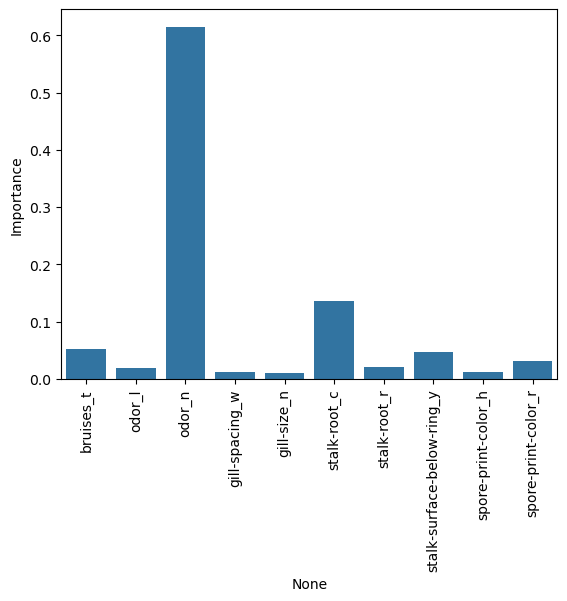

In [101]:
sns.barplot(data=imp, x=imp.index, y = 'Importance')
plt.xticks(rotation=90)
plt.show()